<a href="https://colab.research.google.com/github/AndySCS/ZW02a-25_FYP_repo/blob/main/ffn_test/jpnb/FYP_MNIST_NUMBER_QUANT_TF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##mount to drive

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

### TODO: Define the new path for your working directory
new_working_directory = '/content/drive/MyDrive/Colab Notebooks/fyp'

# Change the current working directory to the new path
os.chdir(new_working_directory)

Mounted at /content/drive


#import pkgs

In [ ]:
#import pkgs
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pathlib
from ai_edge_litert.interpreter import Interpreter

#load model

In [ ]:
#model def
model = models.load_model('model.keras')

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 56)             │        43,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,592 (521.85 KB)

 Trainable params: 44,530 (173.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 89,062 (347.90 KB)

#load ds

In [ ]:
# Load the MNIST dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Normalize the dataset
x_train, x_test = x_train / 255.0, x_test / 255.0

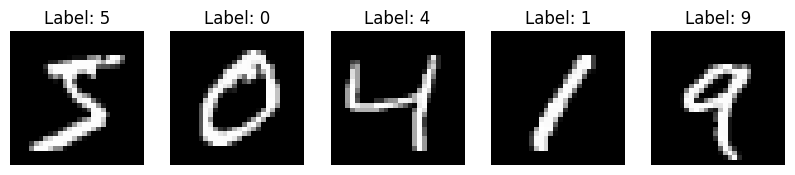

In [ ]:
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')   # MNIST images are grayscale
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

#load weights

In [ ]:
def extract_weights(model):
  weight_list = []
  for layer in model.layers:
      layer_weights = layer.get_weights()  # list of arrays for this layer
      layer_wrights_stack = None
      print(f"Layer: {layer.name}")
      if len(layer_weights) > 0:
        layer_wrights_stack = np.vstack(layer_weights)
        weight_list.append(layer_wrights_stack)
        print(layer_wrights_stack.shape)
      #for arr in layer_weights:
      #  print(arr.shape)   # shape of weights/biases
      #weight_list.append(layer_weights)
  return weight_list


In [ ]:
model_weights = extract_weights(model)

Layer: flatten_1
Layer: dense_2
(785, 56)
Layer: dropout_1
Layer: dense_3
(57, 10)


##convert model

In [ ]:
def quantize_weights(weights, quant_range):
    def quantize_layer(weights, quant_range):
      min_val, max_val = weights.min(), weights.max()
      scale = (2**(quant_range) - 1) / max(abs(min_val), abs(max_val))
      quantized = np.round(weights * scale).astype(np.int8)
      return quantized, scale

    scale_list = []
    quantized_list = []

    for weight in weights:
      quantized, scale = quantize_layer(weight, quant_range)
      quantized_list.append(quantized)
      scale_list.append(scale)

    return quantized_list, scale_list


In [ ]:
q, scale = quantize_weights(model_weights, 4)

print("Quantized:\n", q)
print("Scale:", scale)

Quantized:
 [array([[ 1,  0,  1, ...,  1, -1,  1],
       [ 0, -1,  1, ..., -1, -1,  0],
       [-1, -1,  0, ..., -1, -1,  1],
       ...,
       [-1,  1,  1, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  1, -1],
       [-5,  3,  5, ...,  4,  1,  4]], dtype=int8), array([[  1,   1,   1,   1,  -3,   0,   2, -10,   2,  -1],
       [-10,   1,   2,  -3, -11,  -8,  -8,   1,  -1,  -9],
       [ -5,   4,  -3,   5,  -5,   5, -15,   4,  -7,   4],
       [-11,   5,  -7,   6,   4,   5,  -4,  -5,  -5,   1],
       [ -7,  -5,   2,   3,   3,   0,  -8,   3,   3,   4],
       [ -3,   0,  -8,   3,  -3,   2,   1,  -8,   1,   1],
       [ -8,   4, -10,  -4,  -2,   4,   5,  -5,   2,   0],
       [  4,  -4,   3,  -7,   5,  -4,   5,   4,  -7,  -3],
       [ -3,  -6,   0,   0,   4,  -4,   4,   4,  -8,   4],
       [  4,  -5,   6,   0,  -6,  -5,  -3,   5,  -7,  -7],
       [ -6,   3,  -7,  -7,   4,   3,   1,  -6,   3,  -6],
       [ -9,   4,   4,  -5,  -1,  -6,   2,   0,   1,  -8],
       [  4,  -8,   3,   

## test quant accuracy

In [ ]:
def evaluate_model(model, x_test, y_test):

    # Run inference
    y_pred = model.predict(x_test)

    # If output is logits/probabilities, take argmax
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Ensure labels are integers
    y_true = np.array(y_test).astype(int)

    # Compute accuracy
    accuracy = np.mean(y_pred_classes == y_true)
    return accuracy

#download int8 model

##save param to csv

In [ ]:
import csv

In [ ]:
def save_csv(tensor, file_dir):
  print(tensor.dtype)
  np.savetxt(file_dir, tensor, delimiter=',', fmt='%d')

In [ ]:
def download_weght(q, quant_rng):
  for i in range(len(q)):
    model_layer_weight = q[i].T
    print(model_layer_weight.shape)
    save_csv(model_layer_weight, f"model_layer_weight{i}_int{quant_rng}.csv")

In [ ]:
download_weght(q, 4)

(56, 785)
int8
(10, 57)
int8


#test

In [ ]:
img = x_test[0]
flatten = tf.keras.layers.Flatten()
flatten_img = flatten(img)
save_csv(img, "img.csv")
save_csv(flatten_img, "flatten_img.csv")

float64
<dtype: 'float32'>
